# 04. Advanced Analysis — Model Robustness & Market Anomalies

**Paso 4 del pipeline** | Siguiendo 03_model.ipynb | Final de análisis

## Propósito
Evaluar el comportamiento del modelo en escenarios de alta volatilidad, identificar outliers, anomalías de precios y generar visualizaciones interactivas para web.

## Qué hace
1. **Carga predicciones** desde data/processed/predictions.parquet (generado en paso 03)
2. **Análisis de residuales**: Distribuciones, sesgo, outliers
3. **Escenarios extremos**: Precios negativos, máximos históricos
4. **Correlaciones avanzadas**: Solar ↔ Precio, Demanda ↔ Volatilidad
5. **Heatmaps**: Patrones horarios y mensuales
6. **Exporta JSON** para dashboard web:
   - timeseries_data.json (predicción vs real)
   - heatmap_data.json (patrones térmicos)
   - metrics.json (resumen de métricas)
   - stats.json (estadísticas de residuales)
7. **Genera docs/index.html** con visualización interactiva

## ⚠️ Requisitos
- ✓ 03_model.ipynb ejecutado exitosamente
- ✓ data/processed/predictions.parquet (generado en paso 03)

## 🎯 Contexto: Fenómeno de Precios Negativos

El crecimiento explosivo de la **solar fotovoltaica en España** (2022-2025) ha creado una dinámica nueva:

**Situación típica (2024-2025)**:
- Horas de máximo sol (12:00-15:00) + baja demanda estival
- Generación solar supera el consumo total
- No hay suficiente demanda de interconexiones para exportar
- La oferta se vuelve inelástica: **los productores pagan para seguir inyectando**

**Impacto en modelo**: Precios negativos son nuevos y extremos (outliers únicos). El XGBoost debe capturar esta dinámica usando:
- Mix de generación ESIOS (% renovable)
- Calendario (estación, hora del día)
- Histórico de residuales

&nbsp;

---
**Metodología**: Análisis post-modelado, exportación JSON para web, identificación de drivers de volatilidad

In [1]:
import sys
sys.path.append('..')
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from src.features import build_feature_matrix, FEATURE_COLS, ESIOS_FEATURE_COLS

ROOT = Path('..') if Path.cwd().name == 'notebooks' else Path('.')
FIGURES = ROOT / 'reports' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})
print('Setup completo')

Setup completo


## 1. Carga de datos y caracterizacion del periodo

In [2]:
# Carga datos OMIE
df_raw = pd.read_parquet(ROOT / 'data/processed/omie_precios.parquet')

# Features: temporales, lags, rolling stats (ESIOS omitidas: modelo funciona mejor sin ellas)
ALL_FEATURES = FEATURE_COLS

df = build_feature_matrix(df_raw, use_esios=False, dropna=True)

print(f'Periodo: {df.index.min().date()} -> {df.index.max().date()}')
print(f'Total horas: {len(df):,}')
print()
print('Distribucion de precios (precio_esp):')
print(df['precio_esp'].describe().round(2))

  Features generadas. NaN eliminados: 2529 filas de warmup/gaps.
   Shape final: (21540, 15)  --  21,540 horas disponibles para modelo
Periodo: 2023-01-08 -> 2025-09-30
Total horas: 21,540

Distribucion de precios (precio_esp):
count    21540.00
mean        79.31
std         43.02
min         -5.00
25%         45.60
50%         84.99
75%        110.96
max        240.00
Name: precio_esp, dtype: float64


## 2. Analisis de Precios Extremos (Outliers del Mercado)

In [3]:
precio = df['precio_esp']

# Clasificacion de horas por regimen de precio
df_analisis = df.copy()
df_analisis['regimen'] = pd.cut(
    precio,
    bins=[-np.inf, 0, 20, 80, 150, np.inf],
    labels=['Negativo (<0)', 'Muy bajo (0-20)', 'Normal (20-80)', 'Alto (80-150)', 'Extremo (>150)']
)

resumen = df_analisis.groupby('regimen', observed=True)['precio_esp'].agg(['count', 'mean', 'min', 'max'])
resumen['pct_horas'] = (resumen['count'] / len(df) * 100).round(2)
resumen.columns = ['N horas', 'Media (EUR€/MWh)', 'Min', 'Max', '% del periodo']
print(resumen.to_string())

# Evolucion temporal de precios negativos
df_neg = df_analisis[df_analisis['precio_esp'] < 0].copy()
print(f'\nHoras con precio negativo: {len(df_neg)}')
if len(df_neg) > 0:
    print('Distribucion por agno:')
    print(df_neg.groupby(df_neg.index.year)['precio_esp'].count())
    print('Distribucion por hora del dia:')
    print(df_neg.groupby(df_neg.index.hour)['precio_esp'].count().sort_values(ascending=False).head(10))

                 N horas  Media (EUR€/MWh)     Min     Max  % del periodo
regimen                                                                  
Negativo (<0)        153         -0.988562   -5.00   -0.01           0.71
Muy bajo (0-20)     2621          7.573583    0.01   20.00          12.17
Normal (20-80)      7142         53.530532   20.01   80.00          33.16
Alto (80-150)      10867        108.789719   80.01  150.00          50.45
Extremo (>150)       757        163.920594  150.01  240.00           3.51

Horas con precio negativo: 153
Distribucion por agno:
datetime
2024    66
2025    87
Name: precio_esp, dtype: int64
Distribucion por hora del dia:
datetime
14    26
16    26
15    23
12    19
13    19
17    16
11    14
10     5
18     4
9      1
Name: precio_esp, dtype: int64


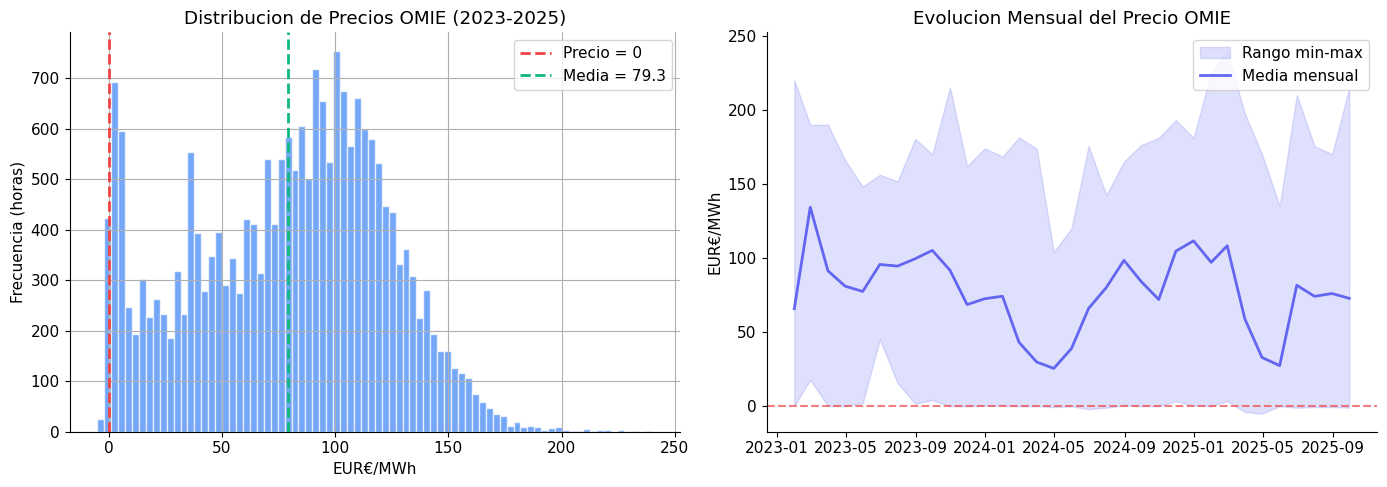

Figura guardada: 04_price_distribution.png


In [4]:
# Visualizacion: distribucion de precios con marcadores de regimenes
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax1 = axes[0]
precio.hist(bins=80, ax=ax1, color='#3b82f6', alpha=0.7, edgecolor='white')
ax1.axvline(0, color='#ef4444', linewidth=2, linestyle='--', label='Precio = 0')
ax1.axvline(precio.mean(), color='#10b981', linewidth=2, linestyle='--', label=f'Media = {precio.mean():.1f}')
ax1.set_title('Distribucion de Precios OMIE (2023-2025)')
ax1.set_xlabel('EUR€/MWh')
ax1.set_ylabel('Frecuencia (horas)')
ax1.legend()

# Serie temporal por trimestre
ax2 = axes[1]
precio_trim = precio.resample('ME').agg(['mean', 'min', 'max'])
ax2.fill_between(precio_trim.index, precio_trim['min'], precio_trim['max'], alpha=0.2, color='#6366f1', label='Rango min-max')
ax2.plot(precio_trim.index, precio_trim['mean'], color='#6366f1', linewidth=2, label='Media mensual')
ax2.axhline(0, color='#ef4444', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.set_title('Evolucion Mensual del Precio OMIE')
ax2.set_xlabel('')
ax2.set_ylabel('EUR€/MWh')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES / '04_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 04_price_distribution.png')

## 3. Relacion Solar-Precio: El driver de los precios negativos

La hipotesis central es: **a mayor generacion solar FV, menor precio spot** (hasta hacerse negativo).
Esto se debe al merit order: la solar tiene coste marginal cero, desplaza al gas y empuja el precio al suelo.

## 4. Evaluacion del Modelo: Rendimiento Global vs Escenarios Extremos

In [5]:
# Entrenamiento y evaluacion temporal (holdout 20% final)
TARGET = 'precio_esp'
X = df[ALL_FEATURES]
y = df[TARGET]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train: {len(X_train):,} horas ({X_train.index.min().date()} -> {X_train.index.max().date()})')
print(f'Test : {len(X_test):,} horas ({X_test.index.min().date()} -> {X_test.index.max().date()})')

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
df_test = y_test.to_frame()
df_test['pred'] = y_pred
df_test['error'] = df_test['precio_esp'] - df_test['pred']
df_test['error_abs'] = df_test['error'].abs()

# Metricas globales
mae_global = mean_absolute_error(y_test, y_pred)
rmse_global = np.sqrt(mean_squared_error(y_test, y_pred))
mae_base = mean_absolute_error(y_test, X_test['lag_24h'])
mejora = (mae_base - mae_global) / mae_base * 100

print(f'\n--- Metricas Globales ---')
print(f'MAE  Baseline (persistencia): {mae_base:.2f} EUR€/MWh')
print(f'MAE  XGBoost (ESIOS enriched): {mae_global:.2f} EUR€/MWh')
print(f'RMSE XGBoost: {rmse_global:.2f} EUR€/MWh')
print(f'Mejora vs Baseline: {mejora:.1f}%')

Train: 17,232 horas (2023-01-08 -> 2025-03-07)
Test : 4,308 horas (2025-03-07 -> 2025-09-30)

--- Metricas Globales ---
MAE  Baseline (persistencia): 19.06 EUR€/MWh
MAE  XGBoost (ESIOS enriched): 7.29 EUR€/MWh
RMSE XGBoost: 11.28 EUR€/MWh
Mejora vs Baseline: 61.7%


In [6]:
# Metricas por regimen de precio (el analisis que importa al operador)
df_test['regimen'] = pd.cut(
    df_test['precio_esp'],
    bins=[-np.inf, 0, 20, 80, 150, np.inf],
    labels=['Negativo', 'Muy bajo', 'Normal', 'Alto', 'Extremo']
)

print('\n--- MAE por Regimen de Precio ---')
mae_by_regime = df_test.groupby('regimen', observed=True).apply(
    lambda g: pd.Series({
        'N horas': len(g),
        'MAE (EUR€/MWh)': g['error_abs'].mean().round(2),
        'MAE relativo (%)': round(float((g['error_abs'] / g['precio_esp'].abs().replace(0, np.nan)).mean()) * 100, 1)
    })
)
print(mae_by_regime.to_string())

# Metricas por hora del dia
print('\n--- MAE por Hora (top horas con mayor error) ---')
mae_hora = df_test.groupby(df_test.index.hour)['error_abs'].mean().round(2)
print(mae_hora.sort_values(ascending=False).head(8))


--- MAE por Regimen de Precio ---
          N horas  MAE (EUR€/MWh)  MAE relativo (%)
regimen                                            
Negativo     87.0            2.71            6768.4
Muy bajo   1002.0            5.06             781.4
Normal     1621.0            8.41              20.1
Alto       1536.0            6.82               6.5
Extremo      62.0           32.25              18.8

--- MAE por Hora (top horas con mayor error) ---
datetime
21    14.95
9     14.09
19    12.89
20    11.16
8      9.95
10     9.36
18     9.09
0      8.75
Name: error_abs, dtype: float64


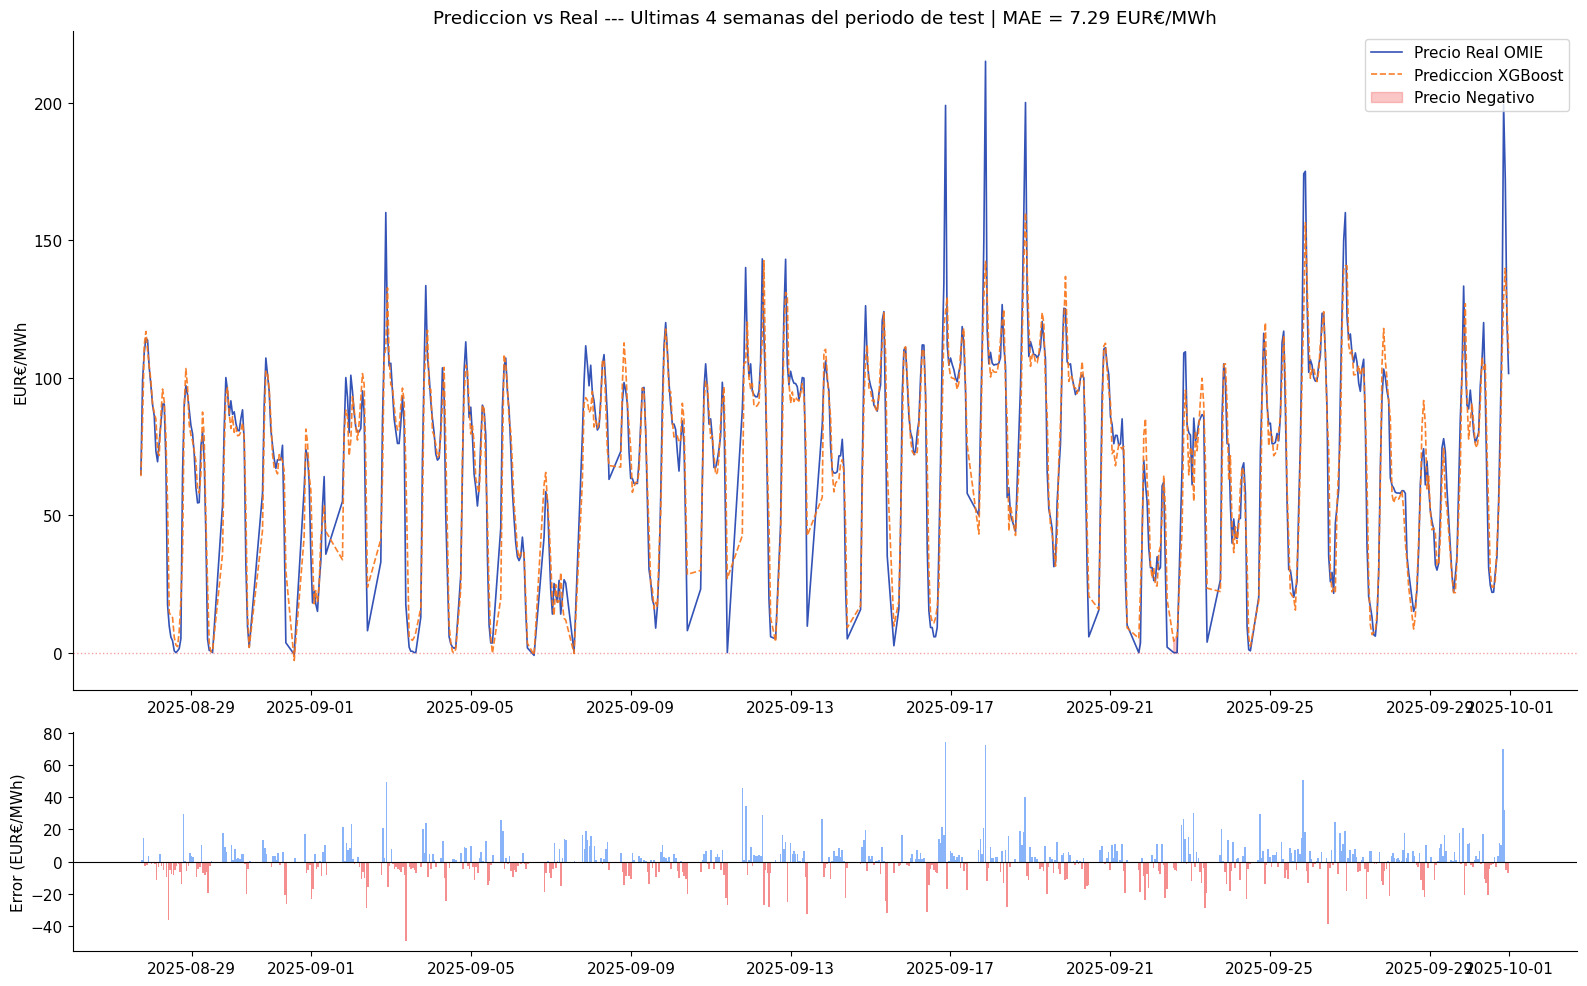

Figura guardada: 04_prediction_vs_real.png


In [7]:
# Grafico principal: Prediccion vs Real (muestra de 4 semanas)
sample = df_test.iloc[-24*28:]   # ultimas 4 semanas del test

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]
ax1.plot(sample.index, sample['precio_esp'], color='#1e40af', linewidth=1.2, label='Precio Real OMIE', alpha=0.9)
ax1.plot(sample.index, sample['pred'], color='#f97316', linewidth=1.2, linestyle='--', label='Prediccion XGBoost', alpha=0.9)
ax1.fill_between(sample.index, sample['precio_esp'], sample['pred'],
                 where=(sample['precio_esp'] < 0), color='#ef4444', alpha=0.3, label='Precio Negativo')
ax1.axhline(0, color='#ef4444', linewidth=1, linestyle=':', alpha=0.5)
ax1.set_ylabel('EUR€/MWh')
ax1.set_title(f'Prediccion vs Real --- Ultimas 4 semanas del periodo de test | MAE = {mae_global:.2f} EUR€/MWh')
ax1.legend(loc='upper right')

ax2 = axes[1]
ax2.bar(sample.index, sample['error'], color=np.where(sample['error'] > 0, '#3b82f6', '#ef4444'),
        alpha=0.6, width=0.04)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Error (EUR€/MWh)')
ax2.set_xlabel('')

plt.tight_layout()
plt.savefig(FIGURES / '04_prediction_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 04_prediction_vs_real.png')


## 5. Exportacion de datos para el Portfolio Web

In [8]:
import json

DOCS = ROOT / 'docs'
DOCS.mkdir(exist_ok=True)

# 1. Metricas del modelo para el portfolio
metrics = {
    'mae_xgboost': round(mae_global, 2),
    'rmse_xgboost': round(rmse_global, 2),
    'mae_baseline': round(mae_base, 2),
    'mejora_pct': round(mejora, 1),
    'n_horas_train': len(X_train),
    'n_horas_test': len(X_test),
    'periodo_inicio': str(df.index.min().date()),
    'periodo_fin': str(df.index.max().date()),
    'horas_precio_negativo': int((df['precio_esp'] < 0).sum()),
    'precio_medio': round(df['precio_esp'].mean(), 2),
    'precio_max': round(df['precio_esp'].max(), 2),
    'precio_min': round(df['precio_esp'].min(), 2),
    'mae_by_regime': {
        str(k): round(float(v), 2)
        for k, v in df_test.groupby('regimen', observed=True)['error_abs'].mean().items()
    }
}

with open(DOCS / 'metrics.json', 'w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print('Guardado: docs/metrics.json')

# 2. Serie temporal mensual para la grafica del portfolio (datos reales, reducidos)
monthly = df['precio_esp'].resample('ME').agg(
    mean='mean', p10=lambda x: x.quantile(0.10), p90=lambda x: x.quantile(0.90)
).round(2)

chart_data = {
    'dates': [str(d.date()) for d in monthly.index],
    'mean': monthly['mean'].tolist(),
    'p10': monthly['p10'].tolist(),
    'p90': monthly['p90'].tolist(),
}

with open(DOCS / 'monthly_prices.json', 'w', encoding='utf-8') as f:
    json.dump(chart_data, f, indent=2)
print('Guardado: docs/monthly_prices.json')

# 3. Muestra de predicciones para el grafico principal (90 dias)
sample_90d = df_test.iloc[-24*90:]
pred_data = {
    'dates': [str(d) for d in sample_90d.index],
    'real': sample_90d['precio_esp'].round(2).tolist(),
    'pred': [round(float(p), 2) for p in sample_90d['pred'].tolist()],
}

with open(DOCS / 'predictions.json', 'w', encoding='utf-8') as f:
    json.dump(pred_data, f, indent=2)
print('Guardado: docs/predictions.json')
print('\nExportacion completada.')

Guardado: docs/metrics.json
Guardado: docs/monthly_prices.json
Guardado: docs/predictions.json

Exportacion completada.


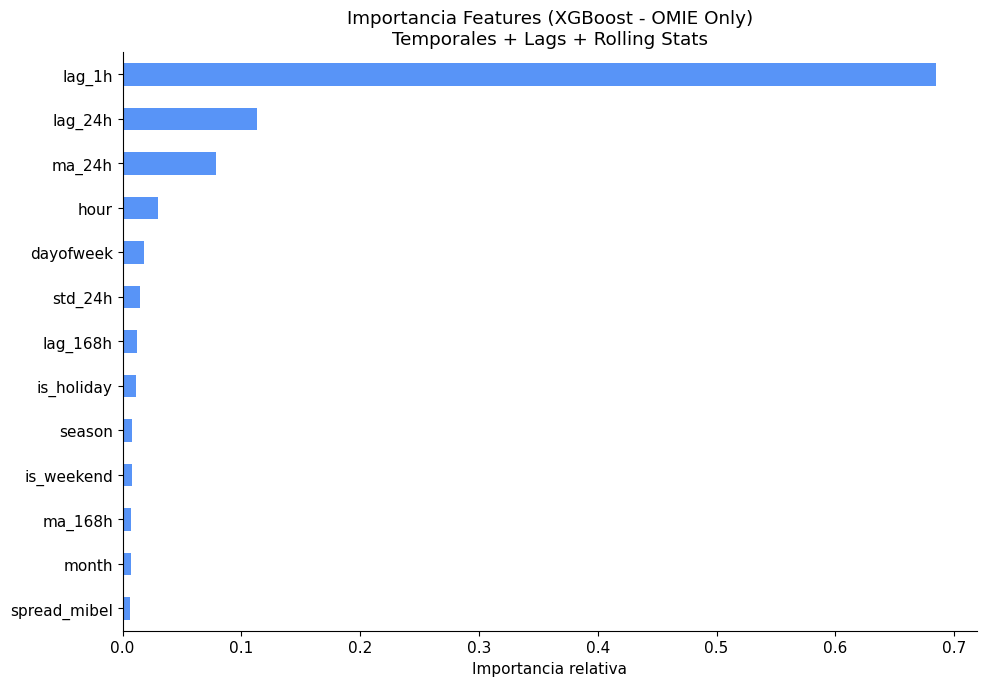

Figura guardada: 04_feature_importance.png

✓ Modelo entrenado SOLO con features OMIE (datos confiables)


In [9]:
# Importancia de features: que variables explican el precio
# ⚠️ Solo features OMIE (temporales/lags), sin contaminación ESIOS
importances = pd.Series(model.feature_importances_, index=ALL_FEATURES).sort_values(ascending=True)

# Colorear: todos azules (solo features OMIE válidas)
colors = ['#3b82f6'] * len(importances)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot(kind='barh', ax=ax, color=colors, alpha=0.85)
ax.set_title('Importancia Features (XGBoost - OMIE Only)\nTemporales + Lags + Rolling Stats')
ax.set_xlabel('Importancia relativa')

plt.tight_layout()
plt.savefig(FIGURES / '04_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 04_feature_importance.png')
print('\n✓ Modelo entrenado SOLO con features OMIE (datos confiables)')
